In [28]:
from reachy2_sdk import ReachySDK
from reachy2_sdk.media.camera import CameraView

# Connessione al robot (usa l'IP corretto del tuo Reachy)
reachy = ReachySDK(host='192.168.0.116') 

print(reachy.cameras)

# Ottieni il frame di profondità e il timestamp
depth_frame, ts = reachy.cameras.depth.get_depth_frame()
frame, ts = reachy.cameras.depth.get_frame()

An instance already exists.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.



<CameraManager initialized_cameras=
	<Camera name="depth" stereo=False> 
	<Camera name="teleop" stereo=True> 
>


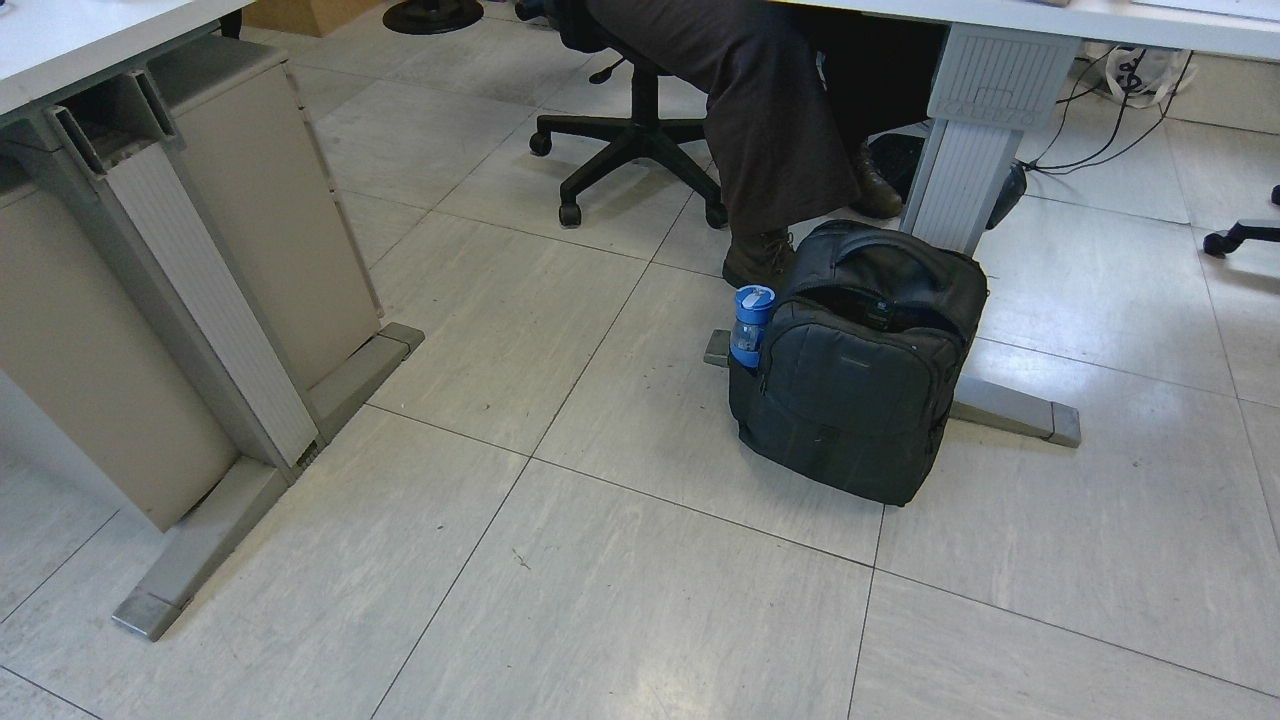

In [29]:
from PIL import Image
Image.fromarray(frame[:,:,::-1])

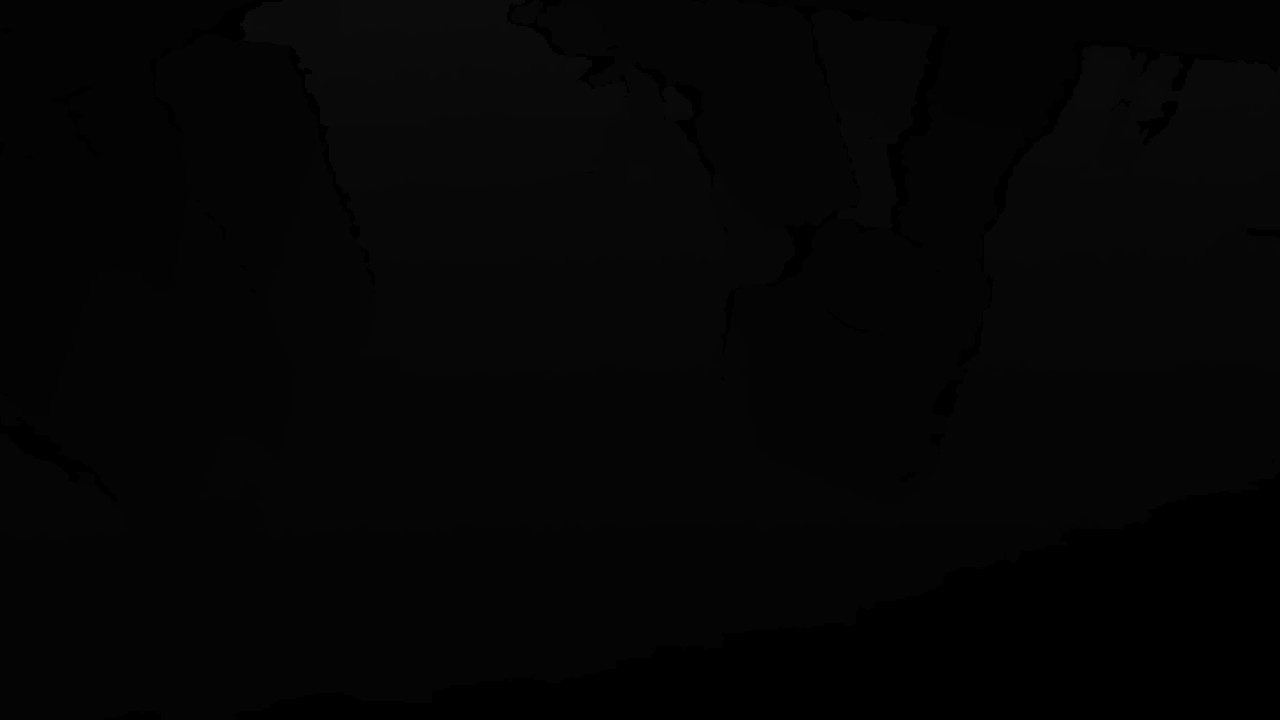

In [30]:
Image.fromarray(depth_frame[:,:])

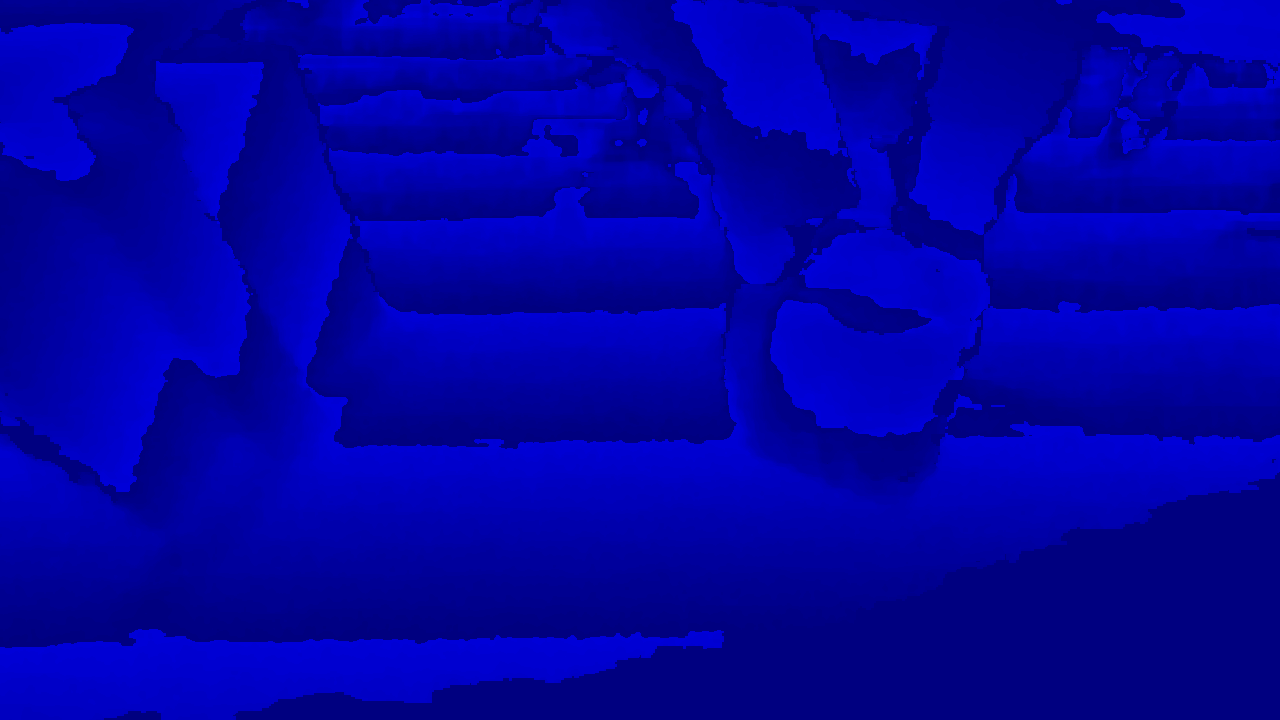

This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.



In [ ]:
import cv2
import numpy as np

def colorize_depth_frame(depth_map):
    # Normalizza i dati per portarli nel range 0-255 (8-bit)
    depth_min = np.min(depth_map)
    depth_max = np.max(depth_map)
    
    if depth_max - depth_min > 0:
        depth_norm = (255 * (depth_map - depth_min) / (depth_max - depth_min)).astype(np.uint8)
    else:
        depth_norm = np.zeros_like(depth_map, dtype=np.uint8)

    # Applica una mappa di colori (COLORMAP_JET è quella standard per la profondità)
    color_depth = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)
    return color_depth

# Applica la conversione
color_depth_image = colorize_depth_frame(depth_frame)

display(Image.fromarray(cv2.cvtColor(color_depth_image, cv2.COLOR_BGR2RGB)))